<a href="https://colab.research.google.com/github/swetha343452-code/MACHINE-LEARNING/blob/main/predict_restaurant_ratings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("/content/Dataset .csv")
print(df.head())
print(df.info())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [2]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [4]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipykernel_2158/2760621050.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [5]:
cat_cols=df.select_dtypes(include=['object']).columns
for col in cat_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_2158/4170548793.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [7]:
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
for col in cat_cols:
  df[col]=Le.fit_transform(df[col])

In [8]:
target="Aggregate rating"

In [10]:
x=df.drop(target,axis=1)
y=df[target]

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [17]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=42)
model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [18]:
y_pred=model.predict(x_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("r^2 Scor:",r2)

MSE: 0.05724228152799579
r^2 Scor: 0.9748508169987886


In [23]:
importance=pd.DataFrame({'Feature':X.columns,
                         'Importance':model.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
print(importance.head(10))

                 Feature  Importance
19                 Votes    0.898958
17          Rating color    0.081987
18           Rating text    0.007401
0          Restaurant ID    0.002368
7              Longitude    0.001426
4                Address    0.001395
1        Restaurant Name    0.001322
9               Cuisines    0.001299
8               Latitude    0.001076
10  Average Cost for two    0.000915


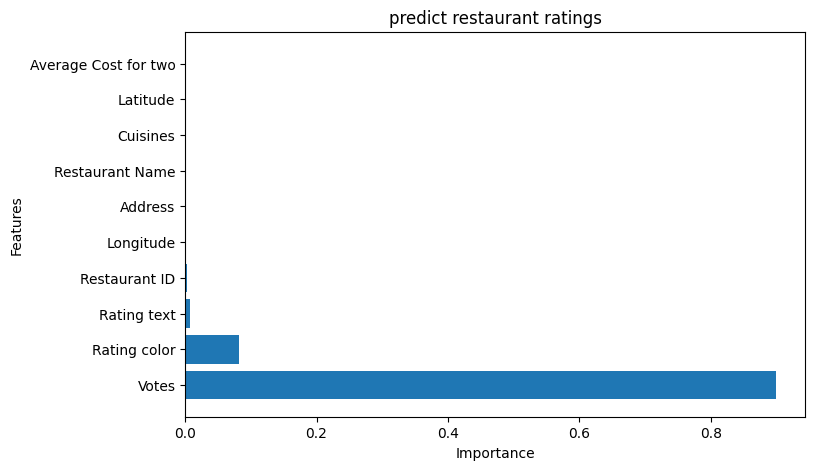

In [24]:
import matplotlib.pyplot as plt
top=importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top['Feature'],top['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("predict restaurant ratings")
plt.show()